In [1]:
import getdist.plots as gdplt
from cobaya import load_samples
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from scipy.optimize import curve_fit

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
plt.rc('font', size=14)
plt.rc('axes', labelsize=16)

# Looking at $w_0 - w_a$ constraints from DESI DR2 data for all but one redshift 

In [2]:
path = r'C:\EPFL\MA4\code\cobaya_runs\DESI_data\base_w_wa\all_but_one_z\all_but_z'
z = 1
path += str(z)

gd_sample = load_samples(path, to_getdist=True, skip=0.33)

var_names = ['hrdrag', 'omm', 'w', 'wa']

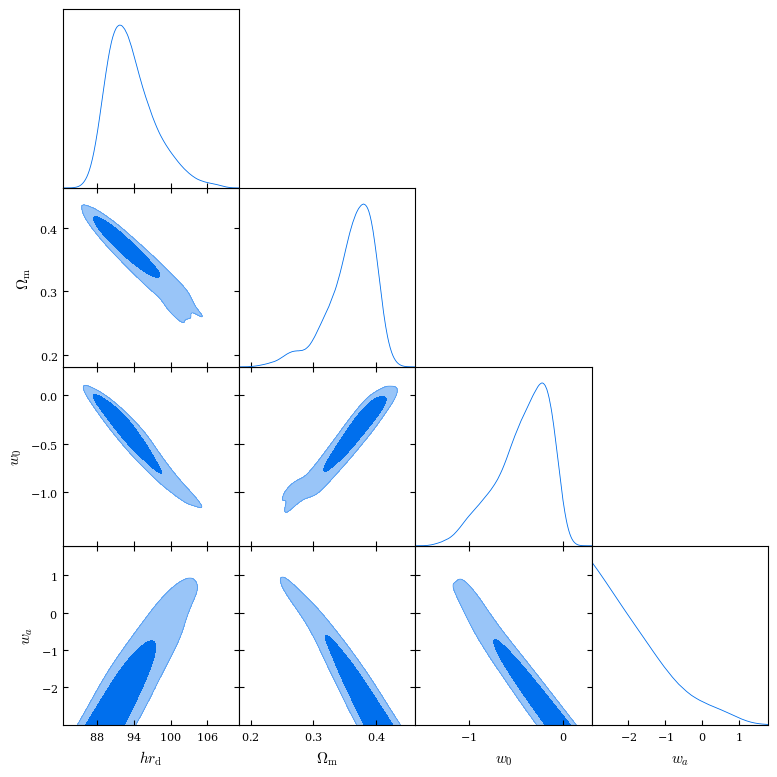

In [3]:
gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, var_names, filled=True)

In [4]:
path = r'C:\EPFL\MA4\code\cobaya_runs\DESI_data\base_w_wa\all_but_one_z\all_but_z'
path_ = [path + str(i) for i in range(1, 8)]

gd_samples = [load_samples(p, to_getdist=True, skip=0.33) for p in path_]

var_names = ['hrdrag', 'omm', 'w', 'wa']
labels = ['No BGS', 'No LRG1', 'No LRG2', 'No LRG3+ELG1', 'No ELG2', 'No QSO', r'No Ly$\alpha$']

labels = ['BGS', 'LRG1', 'LRG2', 'LRG3+ELG1', 'ELG2', 'QSO', r'Ly$\alpha$']
# order = [5, 3, 4, 6, 2, 0, 1]
order = [6, 1, 2, 3, 4, 5, 0]
# order = [0, 1, 2, 3, 4, 5, 6]

# labels.append("All redshifts")
# order.append(7)
# gd_sample_.append(load_samples(path1, to_getdist=True, skip=0.33))

gd_sample_ = [gd_samples[i] for i in order]
labels_ = [labels[i] for i in order]

(-3.0, 1.4)

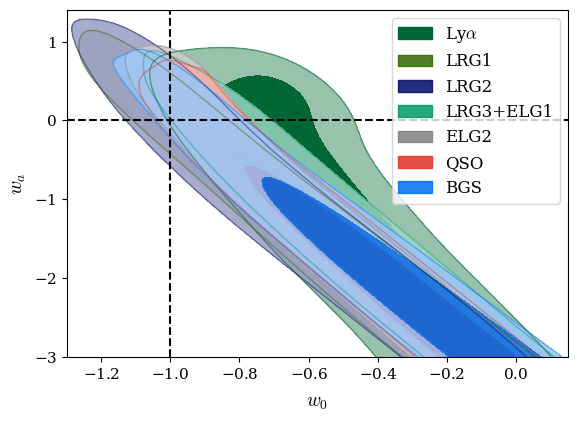

In [5]:
gdplot = gdplt.get_single_plotter()
gdplot.plot_2d(gd_sample_, var_names[2], var_names[3], filled=True)
gdplot.add_legend(labels_, legend_loc='upper right')
plt.axhline(0, color='k', ls='--')
plt.axvline(-1, color='k', ls='--')
plt.xlim(-1.3, 0.15)
plt.ylim(-3, 1.4)

In [6]:
# load all z run
path = r'C:\EPFL\MA4\code\cobaya_runs\DESI_data\base_w_wa\run1'
allz_sample = load_samples(path, to_getdist=True, skip=0.33)

# load individual z constraints with CMB priors
path = []

In [7]:
# x_fit = np.linspace(-2, 1, 10)
# y_fit = -3.66 * (x_fit + 1)
# for i in range(len(gd_samples)):
#     gdplot = gdplt.get_single_plotter()
#     sample_to_plot = [gd_samples[i], allz_sample]
#     gdplot.plot_2d(sample_to_plot, var_names[2], var_names[3], filled=True)
#     labels_to_plot = [labels[i], 'all z']
#     gdplot.add_legend(labels_to_plot, legend_loc='upper right')
#     plt.plot(x_fit, y_fit, ls='-.', color='r', label='Mirage line')
#     plt.axhline(0, color='k', ls='--')
#     plt.axvline(-1, color='k', ls='--')
#     plt.xlim(-1.3, 0.1)
#     plt.ylim(-3, 1.4)
#     if i==3:
#         plt.text(-1.3, -2.5, labels[i], fontsize=12)
#     else:
#         plt.text(-1.2, -2.5, labels[i], fontsize=12)
#     plt.legend()
#     plt.show()
#     #gdplot.export(f'all_but_z{i+1}.png', r'..\figures\DESI_data\all_but_one_z')

In [8]:
path = r'C:\EPFL\MA4\code\cobaya_runs\DESI_data\test_DESI_CMB_lik\DESI_CMB_all_run2'

CMBprior_samples = load_samples(path, to_getdist=True, skip=0.33)

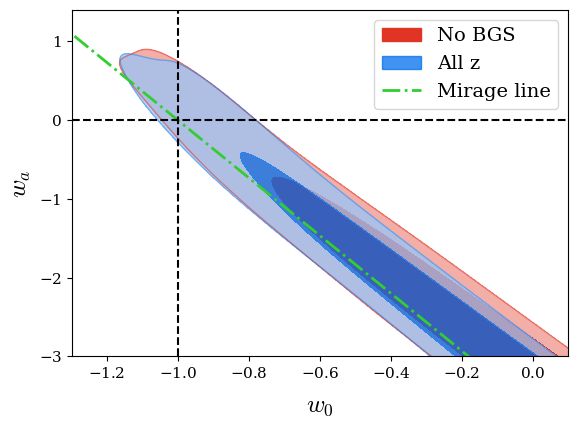

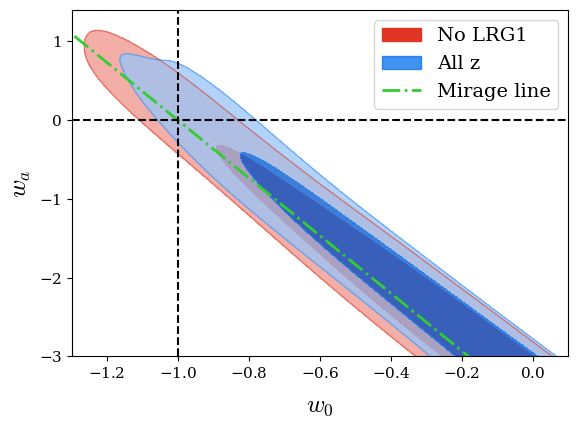

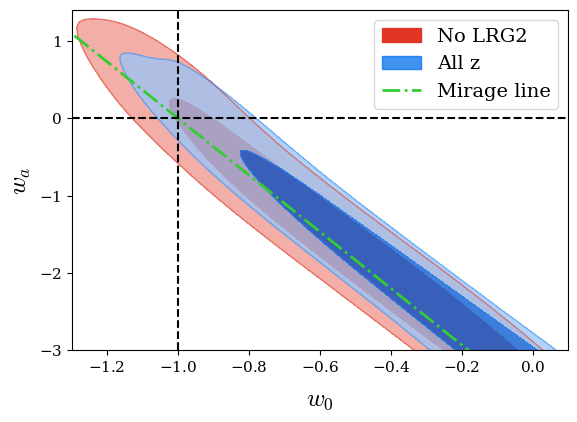

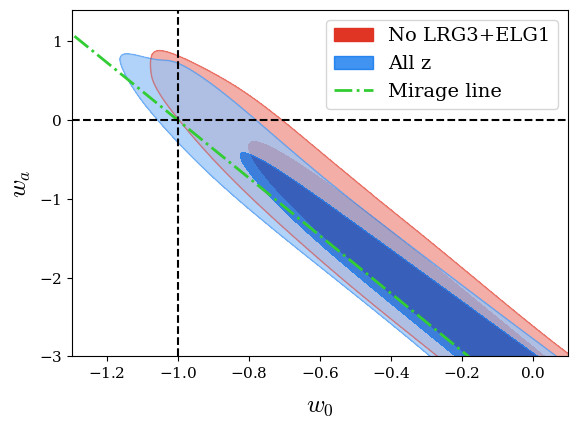

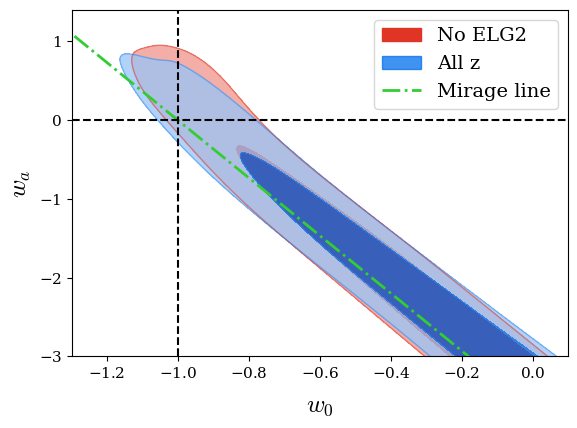

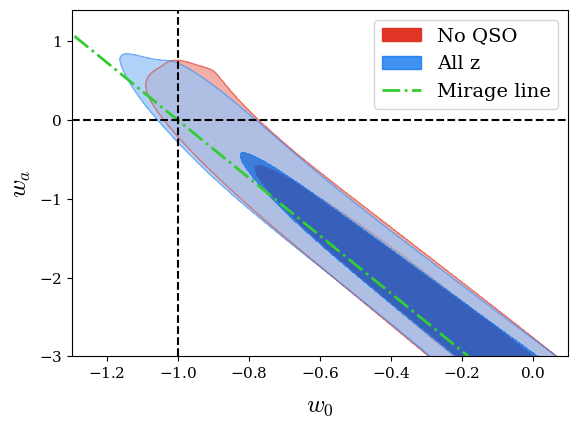

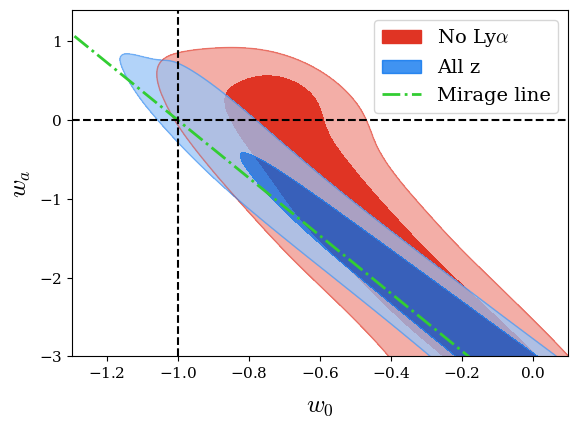

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

x_fit = np.linspace(-2, 1, 10)
y_fit = -3.66 * (x_fit + 1)

for i in range(len(gd_samples)):
    gdplot = gdplt.get_single_plotter()
    sample_to_plot = [gd_samples[i], allz_sample]#, CMBprior_samples]
    gdplot.settings.axes_labelsize = 18
    gdplot.plot_2d(sample_to_plot, var_names[2], var_names[3], filled=True, alphas=[1, 0.75])
    
    ax = plt.gca()
    ax.plot(x_fit, y_fit, ls='-.', color='limegreen', lw=2)
    ax.axhline(0, color='k', ls='--')
    ax.axvline(-1, color='k', ls='--')
    ax.set_xlim(-1.3, 0.1)
    ax.set_ylim(-3, 1.4)

    # Grab the colors getdist used for the filled contours
    colors = gdplot.settings.solid_colors  # list of colors used by getdist

    # Build handles manually
    h1 = mpatches.Patch(color=colors[1], label='No '+labels[i], alpha=1)
    h2 = mpatches.Patch(color=colors[0], label='All z', alpha=0.75)
    # h3 = mpatches.Patch(color=colors[0], label='All z CMB priors', alpha=0.7)
    h4 = mlines.Line2D([], [], color='limegreen', ls='-.', label='Mirage line', lw=2)

    ax.legend(handles=[h1, h2, h4], loc='upper right')

    plt.show()
    # gdplot.export(rf'..\..\figures\DESI_data\all_but_one_z\all_but_z{i+1}.png', dpi=300, bbox_inches='tight')